# 📝 Week 3 — Day 2: Text Features & Classical NLP
### Applied AI & LLM Engineer | Edversity | Phase 2 — Classical ML

---

> **Week:** 3 of 12 &nbsp;|&nbsp; **Phase:** 2 — Classical ML (continued)  
> **Instructor notebook** — run cells top to bottom during lecture.

---

## 🎯 Today's Learning Goals

| # | Goal |
|---|------|
| 1 | Understand **Bag-of-Words**, **TF-IDF**, and **n-grams** |
| 2 | Build a **spam/intent classifier** using classical NLP |
| 3 | Evaluate models with **F1 score** (not just accuracy) |
| 4 | Know **when classical NLP beats LLMs** (speed + cost) |

---

## 📋 Roadmap

```
Section 1 — Text Representation (BoW, TF-IDF, N-grams)
Section 2 — Text Preprocessing Pipeline
Section 3 — Build & Compare Spam Classifiers
Section 4 — Visualise What the Model Learned
Section 5 — Live Predictions & Error Analysis
Section 6 — Bonus: Intent Classifier
```

---

## 🆚 Classical NLP vs LLMs — Quick Reference

| | Classical NLP (TF-IDF) | LLMs (GPT, Claude) |
|---|---|---|
| **Speed** | ~1ms/prediction | ~500ms–2s |
| **Cost** | Free after training | ~$0.001–0.01 per call |
| **Accuracy** | Good for simple tasks | Better for complex tasks |
| **Explainability** | High (you can see weights) | Low (black box) |
| **When to use** | High-volume, simple classification | Nuanced understanding |

> **Rule of thumb:** Try classical NLP first. Only upgrade to LLMs if you need to.

---
## ⚙️ Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Pipeline & evaluation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

# Plotting style
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
np.random.seed(42)

print('✅ All imports successful!')

✅ All imports successful!


---
## 📌 Section 1 — Text Representation

Computers don't understand words — they understand numbers.  
We need to convert text into vectors. Three main approaches:

```
Text  ──►  Numbers  ──►  ML Model
```

### 1.1 — Bag of Words (BoW)

Count how many times each word appears. Ignores word order.

```
Document 1: "I love machine learning"
Document 2: "Machine learning is great"

Vocabulary: {i, love, machine, learning, is, great}

Doc 1 vector: [1, 1, 1, 1, 0, 0]
Doc 2 vector: [0, 0, 1, 1, 1, 1]

Problem: "love" and "machine" have equal weight.
         But "machine" might appear in all ML docs — it's not informative!
```

In [3]:
# ── LIVE DEMO: Bag of Words ──
docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love great food",
]

cv = CountVectorizer()
bow_matrix = cv.fit_transform(docs)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f'Doc {i+1}' for i in range(len(docs))]
)
print('BoW Matrix:')
display(bow_df)

print('\nVocabulary size:', len(cv.vocabulary_))
print('Notice: \"great\" gets same weight in Doc2 and Doc3,')
print('  even though it means very different things.')

BoW Matrix:


,food,great,is,learning,love,machine
Doc 1,0,0,0,1,1,1
Doc 2,0,1,1,1,0,1
Doc 3,1,1,0,0,1,0



Vocabulary size: 6
Notice: "great" gets same weight in Doc2 and Doc3,
  even though it means very different things.


### 1.2 — TF-IDF

**TF-IDF = Term Frequency × Inverse Document Frequency**

- **TF** = how often a word appears in THIS document
- **IDF** = `log(total docs / docs containing the word)`

```
Common words ("the", "is")  → high TF, LOW IDF  → low score (ignored)
Rare, specific words        → moderate TF, HIGH IDF → high score (useful!)
```

**Intuition:** A word that appears in 1 out of 1000 documents is more informative than one that appears in all 1000.

In [4]:
# ── LIVE DEMO: BoW vs TF-IDF ──
spam_docs = [
    "FREE prize win money now",
    "Win FREE cash prize today",
    "FREE entry win now",
    "Hey are you coming tonight",
    "Can you send me the notes",
]

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(spam_docs)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=tfidf.get_feature_names_out(),
    index=[f'Doc {i+1}' for i in range(len(spam_docs))]
)

print('TF-IDF Matrix:')
display(tfidf_df)

print('\n🔍 Key observations:')
print('  "free" appears in Docs 1-3 → medium IDF (not too rare, not too common)')
print('  "tonight" appears only in Doc 4 → high IDF (very informative for that doc)')
print('  Words in all docs get low TF-IDF scores — they carry no signal')

TF-IDF Matrix:


,are,can,cash,coming,entry,free,hey,me,money,notes,now,prize,send,the,today,tonight,win,you
Doc 1,0.000,0.000,0.000,0.000,0.000,0.374,0.000,0.000,0.559,0.000,0.451,0.451,0.000,0.000,0.000,0.000,0.374,0.000
Doc 2,0.000,0.000,0.531,0.000,0.000,0.356,0.000,0.000,0.000,0.000,0.000,0.428,0.000,0.000,0.531,0.000,0.356,0.000
Doc 3,0.000,0.000,0.000,0.000,0.626,0.420,0.000,0.000,0.000,0.000,0.505,0.000,0.000,0.000,0.000,0.000,0.420,0.000
Doc 4,0.464,0.000,0.000,0.464,0.000,0.000,0.464,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.464,0.000,0.374
Doc 5,0.000,0.421,0.000,0.000,0.000,0.000,0.000,0.421,0.000,0.421,0.000,0.000,0.421,0.421,0.000,0.000,0.000,0.339



🔍 Key observations:
  "free" appears in Docs 1-3 → medium IDF (not too rare, not too common)
  "tonight" appears only in Doc 4 → high IDF (very informative for that doc)
  Words in all docs get low TF-IDF scores — they carry no signal


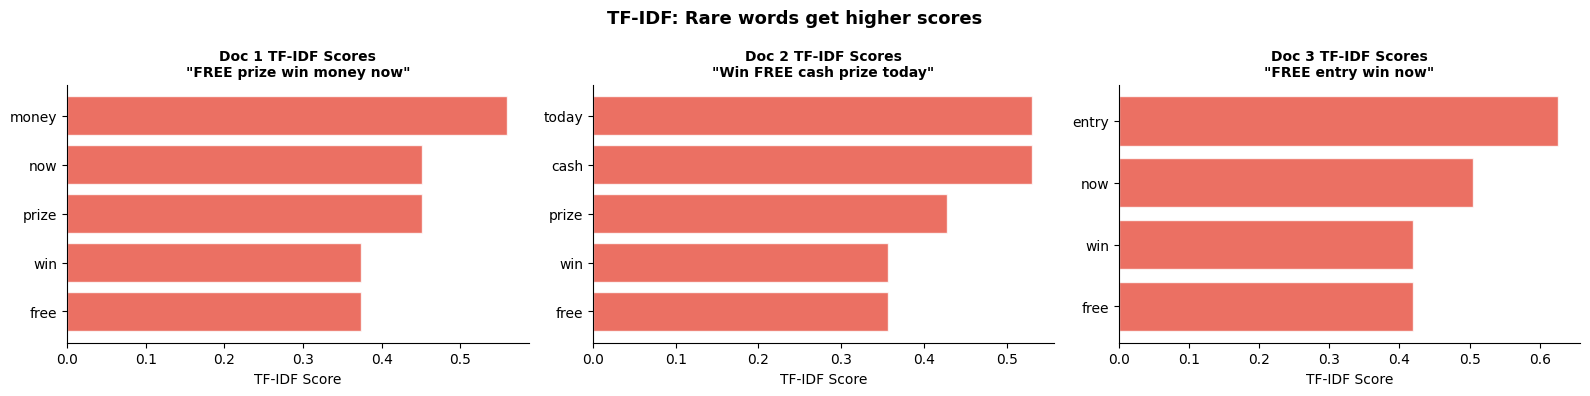

In [5]:
# ── Visualise TF-IDF scores for first 3 docs ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = ['#E74C3C', '#E74C3C', '#E74C3C']
for i, (ax, color) in enumerate(zip(axes, colors)):
    scores = tfidf_df.iloc[i]
    scores = scores[scores > 0].sort_values(ascending=True)
    ax.barh(scores.index, scores.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Doc {i+1} TF-IDF Scores\n"{spam_docs[i][:30]}"', fontsize=10, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')

plt.suptitle('TF-IDF: Rare words get higher scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 — N-grams

Instead of single words, use **sequences of N words** as features.

```
Text: "not good"

Unigrams (1-gram): ["not", "good"]       ← each word separately
Bigrams  (2-gram): ["not good"]           ← captures NEGATION!
Trigrams (3-gram): too sparse usually
```

**Why bigrams matter for spam:**
- `"free"` alone → mildly spam-like
- `"free prize"` → strongly spam-like
- `"free time"` → not spam at all!

In [6]:
# ── DEMO: unigrams vs bigrams ──
text = ["not good product", "very good product", "free prize win now"]

for n, label in [(1, 'Unigrams'), (2, 'Bigrams'), ((1,2), 'Uni+Bigrams')]:
    ngram_range = (n, n) if isinstance(n, int) else n
    cv = CountVectorizer(ngram_range=ngram_range)
    matrix = cv.fit_transform(text)
    print(f'{label}: {list(cv.get_feature_names_out())}')

print('\n💡 Notice: bigrams capture "not good" vs "very good" as separate features!')
print('   ngram_range=(1, 2) gives both unigrams AND bigrams — usually best for spam.')

Unigrams: ['free', 'good', 'not', 'now', 'prize', 'product', 'very', 'win']
Bigrams: ['free prize', 'good product', 'not good', 'prize win', 'very good', 'win now']
Uni+Bigrams: ['free', 'free prize', 'good', 'good product', 'not', 'not good', 'now', 'prize', 'prize win', 'product', 'very', 'very good', 'win', 'win now']

💡 Notice: bigrams capture "not good" vs "very good" as separate features!
   ngram_range=(1, 2) gives both unigrams AND bigrams — usually best for spam.


---
## 📌 Section 2 — Dataset & Text Preprocessing

Raw text is messy. Before vectorizing, we clean it:

```
"FREE prize! You've WON £1000! Click http://scam.com NOW!!"
         ↓  lowercase
"free prize! you've won £1000! click http://scam.com now!!"
         ↓  replace URLs
"free prize! you've won £1000! click URL now!!"
         ↓  replace numbers
"free prize! you've won £NUM! click URL now!!"
         ↓  remove punctuation
"free prize youve won NUM click URL now"
```

In [8]:
# ─────────────────────────────────────────
# Build the spam dataset
# ─────────────────────────────────────────
spam_messages = [
    "FREE entry! Win £1000 cash! Text WIN to 80085 now!",
    "Congratulations! You've won a $500 gift card! Click here!",
    "URGENT: Your account has been compromised! Verify now at http://scam.com",
    "You are a winner! Claim your prize now! Call 0800-FREE",
    "Get rich quick! Make $5000 per day from home! No experience needed!",
    "Your phone number has won the UK lottery prize of £750,000!",
    "FREE ringtones! Download now! Limited offer expires tonight!",
    "WINNER!! As a valued network customer you have been selected",
    "Claim your free gift, just reply GIFT to this number",
    "100% FREE! No charge! Your account has £100 bonus waiting!",
] * 50

ham_messages = [
    "Hey, are you coming to the party tomorrow?",
    "Can you pick up some milk on your way home?",
    "The meeting has been rescheduled to 3pm",
    "I'll be there in 10 minutes, just finishing up",
    "Happy birthday! Hope you have a great day",
    "Did you watch the game last night? Amazing result!",
    "Can we reschedule our lunch to Thursday?",
    "Thanks for the help earlier, really appreciate it",
    "What time does the flight leave? I need to book a cab",
    "The report is ready, I'll send it to you shortly",
    "Are you free this weekend? Want to catch up?",
    "Just checking in, how are you doing?",
] * 50

# Combine and shuffle
messages = spam_messages + ham_messages
labels   = ['spam'] * len(spam_messages) + ['ham'] * len(ham_messages)
messages = [msg + ' ' + str(np.random.randint(100, 999)) for msg in messages]  # add noise

df = pd.DataFrame({'message': messages, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset: {len(df)} messages')
print(df['label'].value_counts())
display(df.head(6))

Dataset: 1100 messages
label
ham     600
spam    500
Name: count, dtype: int64


,message,label
0,"Claim your free gift, just reply GIFT to this ...",spam
1,What time does the flight leave? I need to boo...,ham
2,You are a winner! Claim your prize now! Call 0...,spam
3,"Hey, are you coming to the party tomorrow? 289",ham
4,Get rich quick! Make $5000 per day from home! ...,spam
5,"Thanks for the help earlier, really appreciate...",ham


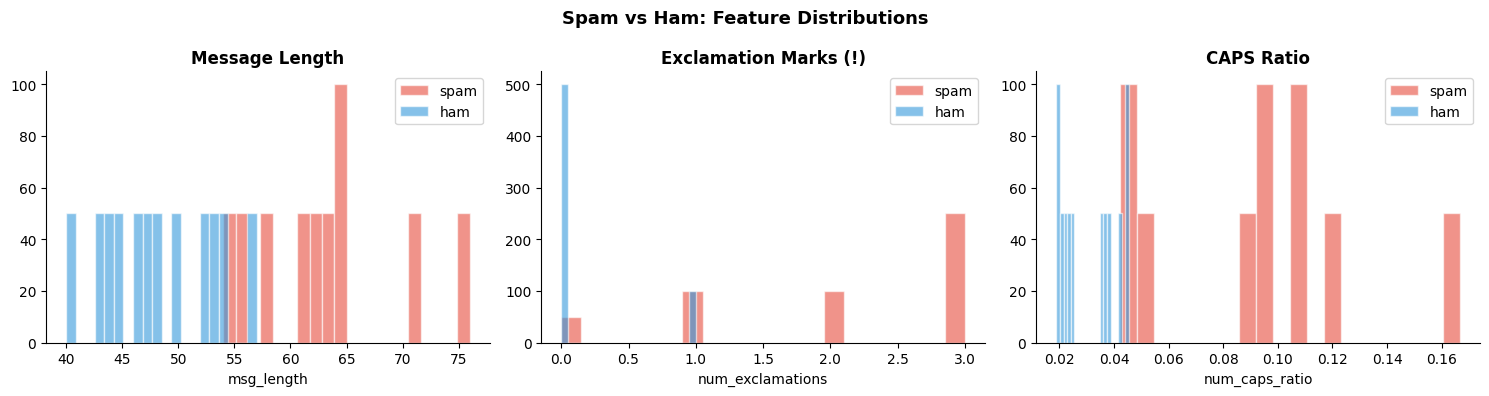

📊 Spam messages tend to be longer, use more ! marks, and more CAPS.
   These could be useful hand-crafted features alongside TF-IDF.


In [9]:
# ── Quick EDA: message length distribution ──
df['msg_length'] = df['message'].str.len()
df['num_exclamations'] = df['message'].str.count('!')
df['num_caps_ratio']   = df['message'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['msg_length', 'num_exclamations', 'num_caps_ratio'],
    ['Message Length', 'Exclamation Marks (!)', 'CAPS Ratio']):
    for label, color in [('spam', '#E74C3C'), ('ham', '#3498DB')]:
        ax.hist(df[df['label']==label][col], bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Spam vs Ham: Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📊 Spam messages tend to be longer, use more ! marks, and more CAPS.')
print('   These could be useful hand-crafted features alongside TF-IDF.')

In [10]:
# ── Text Preprocessing Function ──
def preprocess_text(text: str) -> str:
    """Normalise raw message text for ML."""
    text = text.lower()                            # lowercase
    text = re.sub(r'http\S+|www\S+', 'URL', text) # replace URLs with token
    text = re.sub(r'\d+', 'NUM', text)            # replace numbers with token
    text = re.sub(r'[^\w\s]', '', text)           # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

# Apply preprocessing
df['message_clean'] = df['message'].apply(preprocess_text)

print('=== Preprocessing Examples ===')
for _, row in df.sample(4, random_state=7).iterrows():
    print(f"\n[{row['label'].upper()}]")
    print(f"  Raw:   {row['message'][:80]}")
    print(f"  Clean: {row['message_clean'][:80]}")

=== Preprocessing Examples ===

[SPAM]
  Raw:   WINNER!! As a valued network customer you have been selected 158
  Clean: winner as a valued network customer you have been selected NUM

[SPAM]
  Raw:   You are a winner! Claim your prize now! Call 0800-FREE 815
  Clean: you are a winner claim your prize now call NUMfree NUM

[HAM]
  Raw:   Are you free this weekend? Want to catch up? 869
  Clean: are you free this weekend want to catch up NUM

[SPAM]
  Raw:   Congratulations! You've won a $500 gift card! Click here! 509
  Clean: congratulations youve won a NUM gift card click here NUM


In [11]:
# ── Train / Test Split ──
X = df['message_clean']
y = (df['label'] == 'spam').astype(int)  # 1 = spam, 0 = ham

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')
print(f'Train spam rate: {y_train.mean():.1%}  |  Test spam rate: {y_test.mean():.1%}')
print('✅ stratify=y ensures same spam ratio in train and test')

Train: 880 samples  |  Test: 220 samples
Train spam rate: 45.5%  |  Test spam rate: 45.5%
✅ stratify=y ensures same spam ratio in train and test


---
## 📌 Section 3 — Build & Compare Spam Classifiers

We'll use **sklearn Pipeline** — it chains vectorizer + classifier into one object.

```
Text → [Vectorizer] → [Classifier] → Prediction
        (TF-IDF)       (LogReg)
```

**Advantages of Pipeline:**
- No data leakage (vectorizer fitted on train only)
- One `.fit()` call trains everything
- One `.predict()` call makes predictions
- Works with `GridSearchCV` out of the box

**Three models to compare:**

| Pipeline | Vectorizer | Classifier | Why |
|---|---|---|---|
| A | BoW | Naive Bayes | Classic spam baseline |
| B | TF-IDF | Logistic Regression | Strong linear model |
| C | TF-IDF | LinearSVC | Often best for text |

In [12]:
# ─────────────────────────────────────────
# Define Pipelines
# ─────────────────────────────────────────
pipelines = {
    'BoW + Naive Bayes': Pipeline([
        ('vectorizer', CountVectorizer(max_features=5000, ngram_range=(1, 1))),
        ('classifier', MultinomialNB(alpha=0.1))
    ]),
    'TF-IDF + Logistic Regression': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'TF-IDF + LinearSVC': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('classifier', LinearSVC(random_state=42))
    ]),
}

print('Pipelines defined:')
for name in pipelines:
    print(f'  • {name}')

Pipelines defined:
  • BoW + Naive Bayes
  • TF-IDF + Logistic Regression
  • TF-IDF + LinearSVC


In [13]:
# ─────────────────────────────────────────
# Train all models & collect results
# ─────────────────────────────────────────
results = {}

print('=' * 60)
print('🚀 Training Classifiers')
print('=' * 60)

for name, pipeline in pipelines.items():
    # Train
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Metrics
    f1  = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    cv   = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

    results[name] = {
        'f1': f1, 'precision': prec, 'recall': rec,
        'cv_mean': cv.mean(), 'cv_std': cv.std(),
        'pipeline': pipeline, 'y_pred': y_pred
    }

    print(f'\n📌 {name}')
    print(f'   Test F1:      {f1:.4f}')
    print(f'   Precision:    {prec:.4f}')
    print(f'   Recall:       {rec:.4f}')
    print(f'   CV F1 (5-fold): {cv.mean():.4f} ± {cv.std():.4f}')
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

🚀 Training Classifiers

📌 BoW + Naive Bayes
   Test F1:      1.0000
   Precision:    1.0000
   Recall:       1.0000
   CV F1 (5-fold): 1.0000 ± 0.0000
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       120
        Spam       1.00      1.00      1.00       100

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220


📌 TF-IDF + Logistic Regression
   Test F1:      1.0000
   Precision:    1.0000
   Recall:       1.0000
   CV F1 (5-fold): 1.0000 ± 0.0000
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       120
        Spam       1.00      1.00      1.00       100

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220


📌 TF-IDF + LinearSVC
   Test F1:      1.0000
   Precisi

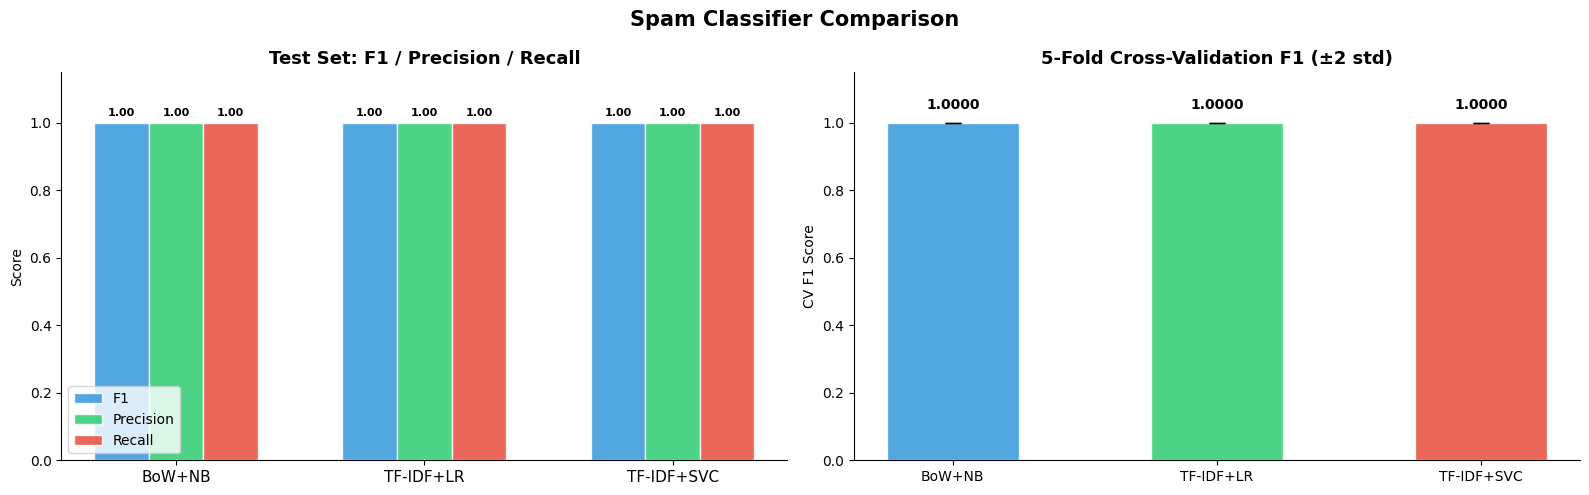


🏆 Best model: BoW + Naive Bayes (CV F1 = 1.0000)


In [14]:
# ── Visualise Model Comparison ──
names    = list(results.keys())
short    = ['BoW+NB', 'TF-IDF+LR', 'TF-IDF+SVC']
f1s      = [results[n]['f1']        for n in names]
precs    = [results[n]['precision'] for n in names]
recalls  = [results[n]['recall']    for n in names]
cv_means = [results[n]['cv_mean']   for n in names]
cv_stds  = [results[n]['cv_std']    for n in names]

x = np.arange(len(names))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar — F1, Precision, Recall
ax = axes[0]
ax.bar(x - w, f1s,     w, label='F1',        color='#3498DB', alpha=0.85, edgecolor='white')
ax.bar(x,     precs,   w, label='Precision', color='#2ECC71', alpha=0.85, edgecolor='white')
ax.bar(x + w, recalls, w, label='Recall',    color='#E74C3C', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(short, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Test Set: F1 / Precision / Recall', fontweight='bold', fontsize=13)
ax.legend()
for xi, (f, p, r) in zip(x, zip(f1s, precs, recalls)):
    for offset, val in [(-w, f), (0, p), (w, r)]:
        ax.text(xi+offset, val+0.02, f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

# Right: CV scores with error bars
ax2 = axes[1]
colors = ['#3498DB', '#2ECC71', '#E74C3C']
bars = ax2.bar(short, cv_means, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax2.errorbar(short, cv_means, yerr=[s*2 for s in cv_stds],
             fmt='none', color='black', capsize=6, linewidth=2)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('CV F1 Score')
ax2.set_title('5-Fold Cross-Validation F1 (±2 std)', fontweight='bold', fontsize=13)
for bar, v in zip(bars, cv_means):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.04, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Spam Classifier Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda n: results[n]['cv_mean'])
print(f'\n🏆 Best model: {best_name} (CV F1 = {results[best_name]["cv_mean"]:.4f})')

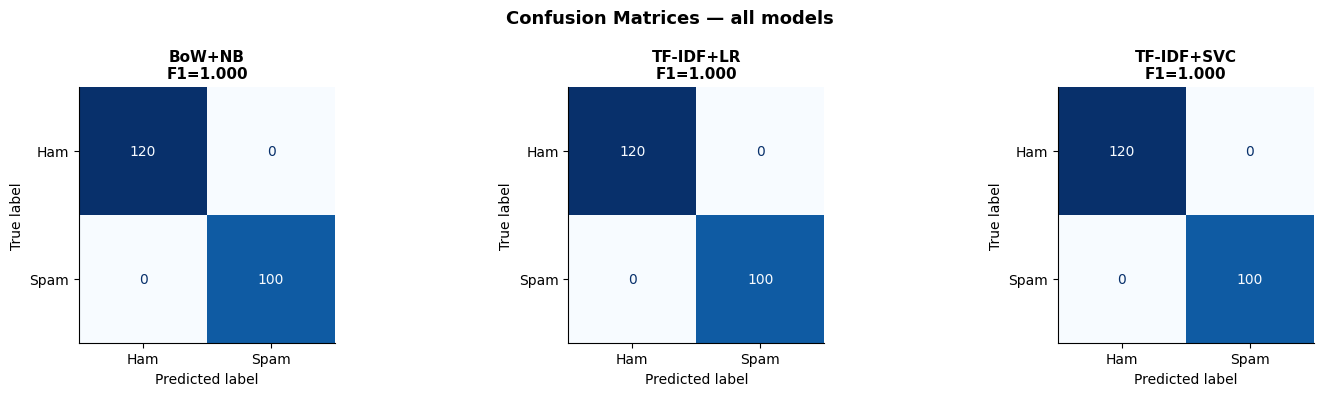


📖 Reading a confusion matrix:
  Top-left:     True Ham  (correctly classified as ham) ← we want this high
  Bottom-right: True Spam (correctly classified as spam) ← we want this high
  Top-right:    False Spam (ham wrongly marked as spam) ← annoying for user
  Bottom-left:  Missed Spam (spam slips through)       ← dangerous!


In [15]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res), short_name in zip(axes, results.items(), short):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{short_name}\nF1={res["f1"]:.3f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — all models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📖 Reading a confusion matrix:')
print('  Top-left:     True Ham  (correctly classified as ham) ← we want this high')
print('  Bottom-right: True Spam (correctly classified as spam) ← we want this high')
print('  Top-right:    False Spam (ham wrongly marked as spam) ← annoying for user')
print('  Bottom-left:  Missed Spam (spam slips through)       ← dangerous!')

---
## 📌 Section 4 — Visualise What the Model Learned

One big advantage of classical NLP: **we can see exactly which words drive predictions.**

For Logistic Regression on TF-IDF features:
- **High positive coefficient** → word strongly indicates SPAM
- **High negative coefficient** → word strongly indicates HAM

In [16]:
# ── Extract LR coefficients ──
best_pipeline  = pipelines['TF-IDF + Logistic Regression']
vectorizer_lr  = best_pipeline.named_steps['vectorizer']
classifier_lr  = best_pipeline.named_steps['classifier']

feature_names = vectorizer_lr.get_feature_names_out()
coef          = classifier_lr.coef_[0]

coef_df   = pd.DataFrame({'word': feature_names, 'coefficient': coef})
top_spam  = coef_df.nlargest(15, 'coefficient')
top_ham   = coef_df.nsmallest(15, 'coefficient')

print(f'Vocabulary size: {len(feature_names)}')
print(f'\nTop 5 SPAM indicators:')
display(top_spam[['word','coefficient']].head())
print(f'\nTop 5 HAM indicators:')
display(top_ham[['word','coefficient']].head())

Vocabulary size: 319

Top 5 SPAM indicators:


,word,coefficient
163,now,1.728979
91,gift,1.654485
311,your,1.456412
293,win,1.293335
296,winner,1.238390



Top 5 HAM indicators:


,word,coefficient
236,the,-1.489840
8,are you,-1.295838
268,up,-1.253640
302,you,-1.198848
253,to,-1.101779


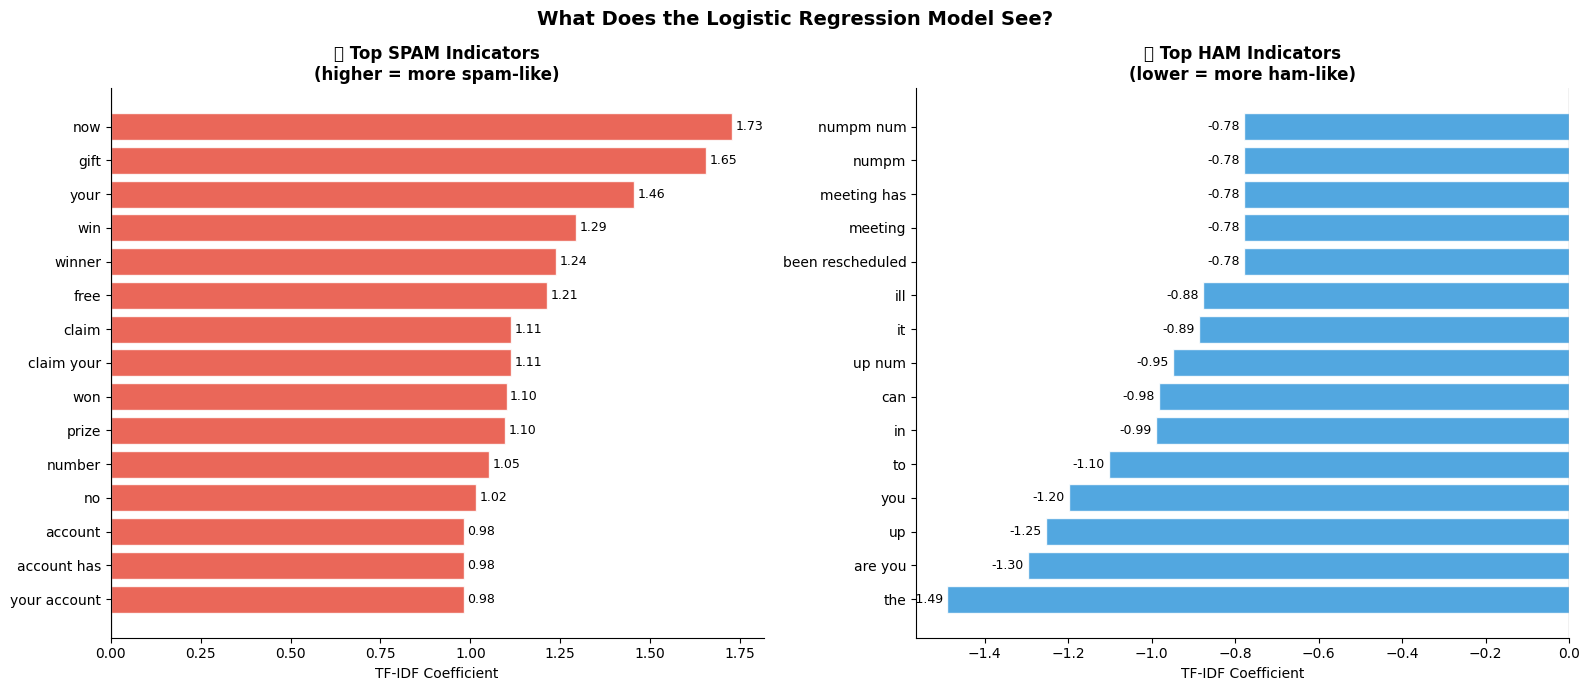

In [17]:
# ── Spam vs Ham Indicator Words Chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# SPAM side
ax = axes[0]
bars = ax.barh(top_spam['word'][::-1], top_spam['coefficient'][::-1],
               color='#E74C3C', alpha=0.85, edgecolor='white')
ax.set_title('🚨 Top SPAM Indicators\n(higher = more spam-like)', fontweight='bold', fontsize=12)
ax.set_xlabel('TF-IDF Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)

# HAM side
ax2 = axes[1]
bars2 = ax2.barh(top_ham['word'], top_ham['coefficient'],
                 color='#3498DB', alpha=0.85, edgecolor='white')
ax2.set_title('✅ Top HAM Indicators\n(lower = more ham-like)', fontweight='bold', fontsize=12)
ax2.set_xlabel('TF-IDF Coefficient')
ax2.axvline(0, color='black', linewidth=0.8)
for bar in bars2:
    ax2.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', ha='right', fontsize=9)

plt.suptitle('What Does the Logistic Regression Model See?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('spam_features.png', dpi=150, bbox_inches='tight')
plt.show()

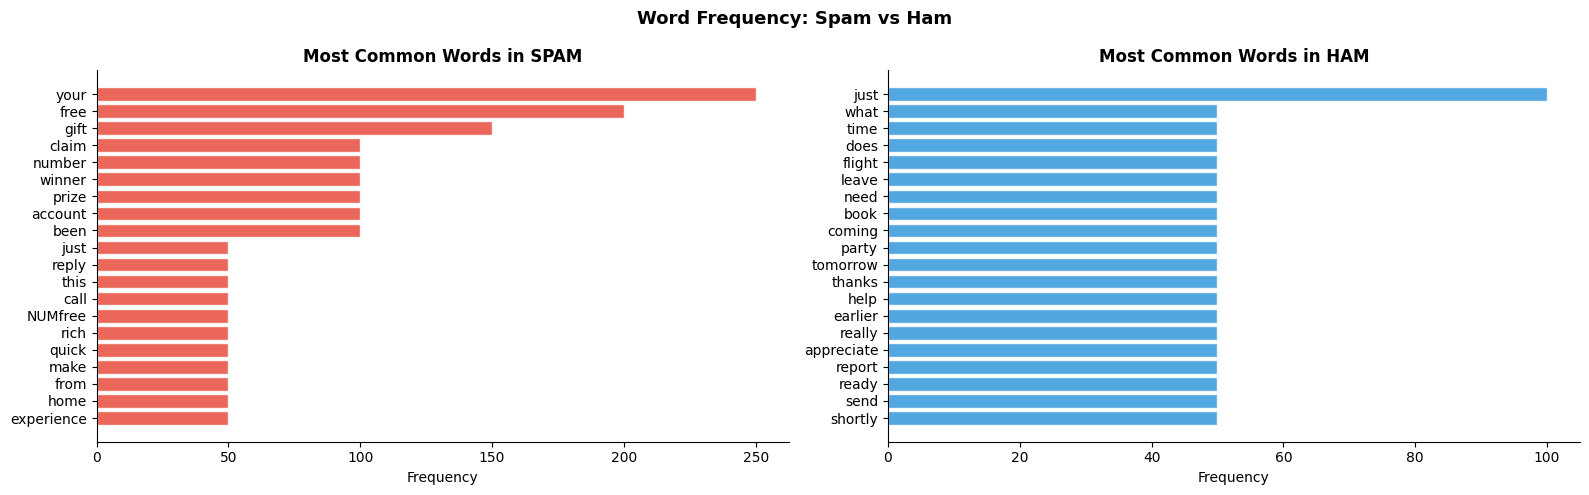

In [18]:
# ── Word frequency comparison: spam vs ham ──
from collections import Counter

def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    # Filter out short/common words
    filtered = [w for w in all_words if len(w) > 3]
    return pd.DataFrame(Counter(filtered).most_common(n), columns=['word', 'count'])

spam_texts = df[df['label']=='spam']['message_clean']
ham_texts  = df[df['label']=='ham']['message_clean']

spam_words = get_top_words(spam_texts)
ham_words  = get_top_words(ham_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(spam_words['word'][::-1], spam_words['count'][::-1],
             color='#E74C3C', alpha=0.85, edgecolor='white')
axes[0].set_title('Most Common Words in SPAM', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Frequency')

axes[1].barh(ham_words['word'][::-1], ham_words['count'][::-1],
             color='#3498DB', alpha=0.85, edgecolor='white')
axes[1].set_title('Most Common Words in HAM', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Frequency')

plt.suptitle('Word Frequency: Spam vs Ham', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📌 Section 5 — Live Predictions & Error Analysis

Let's test our best models on new messages — and look at where they fail.

In [19]:
# ── Live Predictions ──
test_messages = [
    "FREE prize! You've won! Click now!",
    "Hey, can you send me the homework notes?",
    "URGENT: Your bank account needs verification immediately!",
    "Thanks for lunch today, it was great!",
    "Claim your free iPhone 15 now! Limited time offer!",
    "The project deadline is moved to next Friday",
    "You have been selected as a lucky winner! Call now!",
    "Can we reschedule our call to 4pm?",
]

print('=' * 65)
print('🔮 LIVE PREDICTIONS — TF-IDF + Logistic Regression')
print('=' * 65)

lr_pipe = pipelines['TF-IDF + Logistic Regression']

for msg in test_messages:
    clean = preprocess_text(msg)
    pred  = lr_pipe.predict([clean])[0]
    proba = lr_pipe.predict_proba([clean])[0]
    confidence = max(proba)
    label = '🚨 SPAM' if pred == 1 else '✅ HAM '
    bar = '█' * int(confidence * 20)
    print(f"\n  {label}  ({confidence:.0%} confidence)  {bar}")
    print(f"  '{msg[:60]}{'...' if len(msg)>60 else ''}'")

🔮 LIVE PREDICTIONS — TF-IDF + Logistic Regression

  🚨 SPAM  (90% confidence)  █████████████████
  'FREE prize! You've won! Click now!'

  ✅ HAM   (90% confidence)  ██████████████████
  'Hey, can you send me the homework notes?'

  🚨 SPAM  (77% confidence)  ███████████████
  'URGENT: Your bank account needs verification immediately!'

  ✅ HAM   (88% confidence)  █████████████████
  'Thanks for lunch today, it was great!'

  🚨 SPAM  (90% confidence)  █████████████████
  'Claim your free iPhone 15 now! Limited time offer!'

  ✅ HAM   (87% confidence)  █████████████████
  'The project deadline is moved to next Friday'

  🚨 SPAM  (84% confidence)  ████████████████
  'You have been selected as a lucky winner! Call now!'

  ✅ HAM   (91% confidence)  ██████████████████
  'Can we reschedule our call to 4pm?'


In [20]:
# ── Error Analysis: what did the best model get wrong? ──
y_pred_lr = results['TF-IDF + Logistic Regression']['y_pred']

test_df = pd.DataFrame({
    'message': X_test.values,
    'true':    y_test.values,
    'pred':    y_pred_lr
})

false_positives = test_df[(test_df['true']==0) & (test_df['pred']==1)]  # ham → spam (bad!)
false_negatives = test_df[(test_df['true']==1) & (test_df['pred']==0)]  # spam → ham (dangerous!)

print(f'False Positives (ham predicted as spam): {len(false_positives)}')
print(f'False Negatives (spam predicted as ham): {len(false_negatives)}')

if len(false_positives) > 0:
    print('\n📌 Sample False Positives (ham wrongly flagged as spam):')
    for msg in false_positives['message'].head(3):
        print(f'  → "{msg[:70]}"')

if len(false_negatives) > 0:
    print('\n📌 Sample False Negatives (spam that slipped through):')
    for msg in false_negatives['message'].head(3):
        print(f'  → "{msg[:70]}"')

False Positives (ham predicted as spam): 0
False Negatives (spam predicted as ham): 0


---
## 📌 Section 6 — Bonus: Intent Classifier

The **same TF-IDF + classifier approach** works for intent detection in chatbots.

Instead of spam/ham, we classify messages into customer service intents:
- `greeting` — "Hi there!", "Hello"
- `billing` — "My invoice is wrong", "When is payment due?"
- `tech_support` — "App is crashing", "Can't log in"
- `cancellation` — "I want to cancel", "Close my account"
- `general` — Everything else

In [ ]:
# ── Intent Dataset ──
intent_data = {
    'greeting': [
        'Hi there!', 'Hello, how are you?', 'Hey!', 'Good morning',
        'Hi I need help', 'Hello!', 'Hey there', 'Greetings',
        'Good afternoon', 'Hi, can you help me?', 'Hello support team',
        'Hey, quick question', 'Good day', 'Hi team', 'Howdy',
        'Hey, is anyone there?', 'Good evening', 'Hi customer service',
        'Hello, I have a question', 'Hey, need some help'
    ],
    'billing': [
        'My invoice is wrong', 'When is payment due?', 'I was double charged',
        'Can you explain my bill?', 'I want a refund', 'Payment failed',
        'How much does the plan cost?', 'I see an unexpected charge',
        'My credit card was declined', 'Can I get a receipt?',
        'I need to update my payment method', 'What are the pricing plans?',
        'Can I get an invoice for my records?', 'I was overcharged last month',
        'How do I apply a discount code?', 'Can I pay by bank transfer?',
        'When does my subscription renew?', 'I need to cancel my payment',
        'My free trial ended but I was charged', 'Can I change my billing cycle?'
    ],
    'tech_support': [
        'The app keeps crashing', 'I cannot log in', 'My password does not work',
        'The website is down', 'I am getting an error message',
        'The app is slow', 'I lost my data', 'The feature is not working',
        'How do I reset my password?', 'I am having trouble installing the app',
        'The sync is not working', 'I cannot upload files',
        'The app crashes on my iPhone', 'I cannot connect to the server',
        'My notifications are not working', 'The dark mode is broken',
        'I cannot find the settings page', 'The search function is not working',
        'Two factor authentication is not sending codes', 'My account is locked'
    ],
    'cancellation': [
        'I want to cancel my subscription', 'How do I close my account?',
        'I want to delete my account', 'Please cancel my plan',
        'I no longer need this service', 'How do I unsubscribe?',
        'I want to stop my membership', 'Can I pause my subscription?',
        'I want to downgrade my plan', 'How do I opt out?',
        'Please remove my account', 'I want to end my subscription',
        'Cancel everything for me', 'I do not want to renew',
        'How do I turn off auto-renewal?', 'I want a refund and cancellation',
        'Please stop charging me', 'I am leaving the service',
        'I switched to a competitor', 'Please deactivate my account'
    ],
    'general': [
        'What are your office hours?', 'Do you have a mobile app?',
        'What countries do you support?', 'How many users can I add?',
        'Do you offer a student discount?', 'Can I export my data?',
        'How do I contact support?', 'Do you have a free plan?',
        'What is your privacy policy?', 'Can I use this offline?',
        'How secure is my data?', 'Do you have an API?',
        'What languages do you support?', 'Can I integrate with Slack?',
        'How do I invite team members?', 'What is the maximum file size?',
        'Do you have a desktop app?', 'Can I share my account?',
        'What browsers do you support?', 'How do I change my username?'
    ],
}

# Build DataFrame
intent_rows = []
for intent, messages in intent_data.items():
    for msg in messages:
        intent_rows.append({'message': msg, 'intent': intent})

df_intent = pd.DataFrame(intent_rows).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Intent dataset: {len(df_intent)} messages')
print(df_intent['intent'].value_counts())

In [ ]:
# ── Train Intent Classifier ──
X_i = df_intent['message'].apply(preprocess_text)
y_i = df_intent['intent']

X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_i, y_i, test_size=0.25, random_state=42, stratify=y_i
)

intent_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(random_state=42, max_iter=1000, C=5.0))
])

intent_pipeline.fit(X_i_train, y_i_train)
y_i_pred = intent_pipeline.predict(X_i_test)

print('Intent Classifier Results:')
print(classification_report(y_i_test, y_i_pred))

In [ ]:
# ── Confusion Matrix for Intent Classifier ──
cm_intent = confusion_matrix(y_i_test, y_i_pred, labels=list(intent_data.keys()))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_intent, display_labels=list(intent_data.keys()))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Intent Classifier — Confusion Matrix', fontweight='bold', fontsize=13)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# ── Live Intent Prediction ──
customer_messages = [
    "Hi, I need some help",
    "I was charged twice this month",
    "My app won't load",
    "I want to cancel my account please",
    "Do you have a mobile version?",
    "The payment page is broken",
    "Hello there!",
    "I cannot reset my password",
]

intent_labels = {
    'greeting':     '👋',
    'billing':      '💰',
    'tech_support': '🔧',
    'cancellation': '❌',
    'general':      '❓',
}

print('=' * 60)
print('🤖 INTENT CLASSIFIER — Live Predictions')
print('=' * 60)

for msg in customer_messages:
    clean   = preprocess_text(msg)
    intent  = intent_pipeline.predict([clean])[0]
    proba   = intent_pipeline.predict_proba([clean])[0]
    conf    = max(proba)
    emoji   = intent_labels[intent]
    print(f"  {emoji} [{intent:<14}] ({conf:.0%})  '{msg}'")

---
## ✅ Day 2 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Bag of Words** | Counts word occurrences — simple but loses word importance |
| **TF-IDF** | Weights rare/informative words higher — much better than BoW |
| **N-grams** | Captures multi-word phrases like "not good" or "free prize" |
| **Pipeline** | Chains vectorizer + classifier; prevents data leakage |
| **F1 Score** | Better than accuracy for imbalanced classes |
| **Logistic Regression** | Interpretable: you can see which words drive the prediction |
| **Intent Classifier** | Same approach scales to multi-class NLP problems |

---

## 🏋️ Practice — Try These Before Day 3

**🟢 Beginner**
1. What does `ngram_range=(1, 2)` do? Give an example bigram from `"very good product"`.
2. Why is Naive Bayes often good for spam classification despite its "naive" assumption?
3. Add `stop_words='english'` to the TF-IDF vectorizer. Does it improve the F1 score?

**🟡 Intermediate**

4. Add hand-crafted features (`message_length`, `num_exclamation_marks`, `caps_ratio`) alongside TF-IDF using `FeatureUnion`.
5. Use `GridSearchCV` to tune the TF-IDF+LR pipeline (`max_features`, `ngram_range`, `C`). Report the best hyperparameters.

**🔴 Advanced**

6. Compare TF-IDF with **Word2Vec average embeddings** using `gensim`. Which performs better on spam detection?
7. Build a **multi-label classifier** where a message can have multiple tags (`urgent`, `financial`, `personal`) using `MultiLabelBinarizer`.

---

## 📚 Resources
- [sklearn Text Feature Extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
- [TF-IDF Explained — CodeEmporium](https://www.youtube.com/watch?v=D2V1okCEsiE)
- [SMS Spam Dataset — UCI](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection)
- [Text Classification from Scratch](https://medium.com/towards-data-science/text-classification-with-nlp)

---

## 🔜 Coming Up: Day 3 — ML API Deployment

Tomorrow we take today's best model and deploy it as a production FastAPI:
- Save/load the trained pipeline with `joblib`
- Build `/predict` and `/predict/batch` endpoints
- Add health checks, logging, and model versioning

---
*Week 3 Day 2 | Applied AI & LLM Engineer | Edversity*